In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import jit


### Variable

In [2]:
dim = 100
I = 1 # A
hx = 1 # pas spatial
hy = 1 # pas spatial

x = np.linspace(0, dim, dim)
y = np.linspace(0, dim, dim)

xx, yy = np.meshgrid(x, y)

# demi_dist = 5

A = (dim-2, (dim//2)-4)
B = (dim-2, (dim//2)+4)
# M = (48, 98)
# N = (51, 98)

M = (dim-2, (dim//2)-2)
N = (dim-2, (dim//2)+2)


### On met une matrice de conductivité

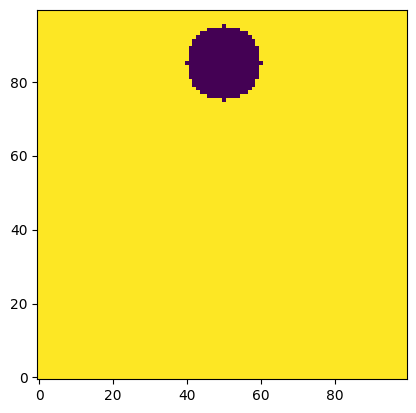

In [ ]:
sigma_init = np.ones((dim, dim))# np.random.uniform(low=1, high=10, size=(dim, dim))

xx, yy = np.meshgrid(np.arange(dim), np.arange(dim), indexing='ij')

sigma_init[(xx-85)**2 + (yy-50)**2 <= 10**2] = 1000


# sigma_init[: 90, dim//2 - 50: dim//2 + 50] = 1000

pot_init = np.zeros((dim, dim))

courant_init = np.zeros((dim, dim))
courant_init[A[0], A[1]] = I
courant_init[B[0], B[1]] = -I

plt.figure()
plt.imshow(sigma_init, origin='lower')

# plt.imshow(courant_init, origin='lower')



### Calcul du potentiel

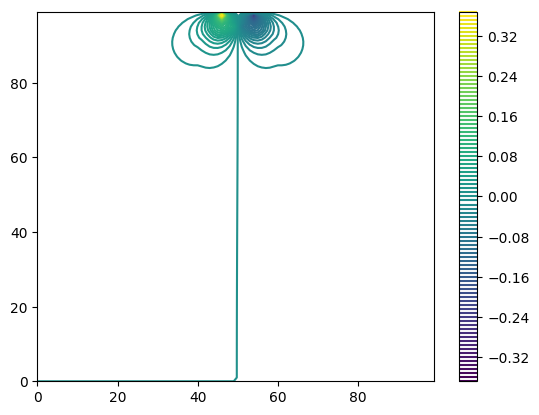

In [4]:
import numpy as np
import numba

@numba.njit(fastmath=True, parallel=True)
def compute_pot(V, V_k, Sigma, I):
    l = V.shape[0]
    h2 = 1.0  # h^2

    for j in numba.prange(1, l-1):
        for i in range(1, l-1):

            s = Sigma[j, i]

            sip = Sigma[j, i+1]
            sim = Sigma[j, i-1]
            sjp = Sigma[j+1, i]
            sjm = Sigma[j-1, i]

            sigma_ifhs = 2*s*sip / (s + sip)
            sigma_ibhs = 2*s*sim / (s + sim)
            sigma_jfhs = 2*s*sjp / (s + sjp)
            sigma_jbhs = 2*s*sjm / (s + sjm)

            deno = sigma_ifhs + sigma_ibhs + sigma_jfhs + sigma_jbhs

            V[j, i] = (
                I[j, i]*h2
                + sigma_ifhs*V_k[j, i+1]
                + sigma_ibhs*V_k[j, i-1]
                + sigma_jfhs*V_k[j+1, i]
                + sigma_jbhs*V_k[j-1, i]
            ) / deno

    return V


@numba.njit(fastmath=True)
def compute_error(V, V_k):
    err = 0.0
    for j in range(V.shape[0]):
        for i in range(V.shape[1]):
            d = V[j, i] - V_k[j, i]
            err += d*d
    return np.sqrt(err)


@numba.njit(fastmath=True)
def apply_bc(V, DIM):
    # conditions limites
    V[0, :] = 0
    V[-1, :] = 0#V[-1, :] = V[-2, :]#
    V[:, 0] = V[:, 1]
    V[:, DIM-1] = V[:, DIM-2]


@numba.njit(fastmath=True)
def find_pot(V, Sigma, I, DIM, tol=1e-5, niter=1000000):

    for _ in range(niter):

        V_k = V.copy()

        apply_bc(V, DIM)

        compute_pot(V, V_k, Sigma, I)

        error = compute_error(V, V_k)

        if error < tol:
            break

    return V

Voltage = find_pot(pot_init, sigma_init, courant_init, DIM=dim)

# print(f"Nombre d'itérations: {it}")
# print(f"Erreur: {error}")


plt.figure()
# plt.imshow(Voltage, origin='lower')
plt.contour(Voltage, levels=100)
# plt.imshow(pot)
plt.colorbar()
                

### Mesure de la différence de potentiel

In [5]:
# def coord_schlumb(A_i, B_i, max_dist):
#     A_to_move = A_i[1]
#     B_to_move = B_i[1]
#     A_list = []
#     B_list = []
#     for i in range(2, max_dist, 2):
#         A = A_to_move - i
#         B = B_to_move + i
#         A_list.append(A)
#         B_list.append(B)

#     return list(zip(A_list, B_list))

# c = coord_schlumb(A, B, 45)

# def pot_for_schlumb(V, M, N):

#     dV = V[M[0], M[1]] - V[N[0], N[1]]
#     return dV


# def app_res(coord_ab, dimension, cond, I):
#     V_i = np.zeros((dimension, dimension))

#     rho_app = []
#     AB_2 = []

#     for i in coord_ab:
#         a, b = i
#         AB_2.append(abs(b-a)/2)
#         I0 = np.zeros((dimension, dimension))
#         V_i = np.zeros((dimension, dimension))
#         I0[98:, a]=I
#         I0[98:, b]=-I

#         V = find_pot(V_i, cond, I0, DIM=dimension)

#         V_MN = pot_for_schlumb(V, M, N)

#         # print(M, N)
#         # print(a, b)

#         K = np.pi * (((abs(b-a)/2)**2 - (abs(M[1]-N[1])/2)**2) / abs(M[1]-N[1]))#(2 * np.pi) / ((1/abs(a-M[1])) - (1/abs(b-M[1])) - (1/abs(a-N[1])) + (1/abs(b-N[1])))

#         rho_ap = K*V_MN/I
#         rho_app.append(rho_ap)

#     return np.array(rho_app), np.array(AB_2)

# rho_a, ab2 = app_res(c, dim, sigma_init, I)






In [6]:
import numpy as np
from joblib import Parallel, delayed

def coord_schlumb(A_i, B_i, max_dist):
    A_to_move = A_i[1]
    B_to_move = B_i[1]
    A_list = []
    B_list = []
    for i in range(2, max_dist, 2):
        A = A_to_move - i
        B = B_to_move + i
        A_list.append(A)
        B_list.append(B)

    return list(zip(A_list, B_list))

c = coord_schlumb(A, B, 45)

def compute_one_ab(a, b, dimension, cond, I, M, N):
    # Injection courant
    I0 = np.zeros((dimension, dimension))
    I0[98, a] = I
    I0[98, b] = -I

    # Solveur
    V = find_pot(np.zeros((dimension, dimension)), cond, I0, DIM=dimension)

    # Différence de potentiel
    dV = V[M[0], M[1]] - V[N[0], N[1]]

    # Géométrie
    AB = abs(b - a)
    AB_2 = AB / 2

    MN_dist = abs(M[1] - N[1])
    MN_term = (MN_dist / 2)**2

    K = np.pi * ((AB_2**2 - MN_term) / MN_dist)

    rho = K * dV / I

    return rho, AB_2


def app_res_parallel(coord_ab, dimension, cond, I, M, N, n_jobs=-1):

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_one_ab)(a, b, dimension, cond, I, M, N)
        for (a, b) in coord_ab
    )

    rho_app, AB_2 = zip(*results)

    return np.array(rho_app), np.array(AB_2)

In [7]:
rho_a, ab2 = app_res_parallel(c, dim, sigma_init, I, M, N)

### Résistivité apparente du sol

Text(0.5, 0, 'Demi-distance entre les électrodes [m]')

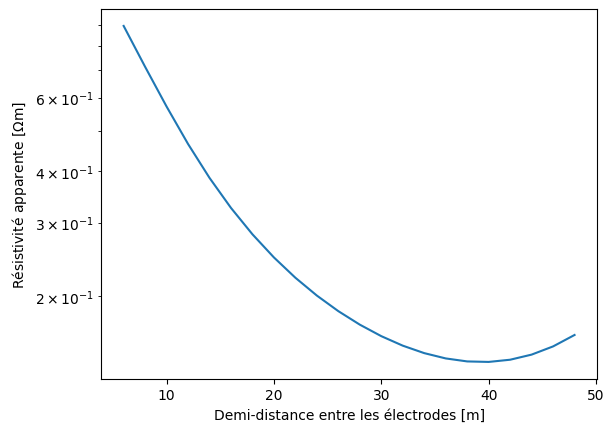

In [8]:


plt.figure()
# plt.contourf(xx, yy, V_[0], levels=200)
plt.plot(ab2, rho_a)
plt.yscale('log')
plt.ylabel(r"Résistivité apparente [$\Omega$m]")
plt.xlabel("Demi-distance entre les électrodes [m]")

# plt.show()

### On trouve la pseudo-section

La pseudo-section est un "mapping" de la résistivité apparent du sous-sol.

In [ ]:
def pseudo_section(dimension, cond, I):
    # pseudo = np.zeros((dimension, dimension))
    rho = []
    x = []
    z = []

    A_i = [dimension-2, 2]
    M_i = [dimension-2, 4]
    N_i = [dimension-2, 6]
    B_i = [dimension-2, 8]

    A_i_modif = A_i.copy()
    B_i_modif = B_i.copy()
    M_i_modif = M_i.copy()
    N_i_modif = N_i.copy()

    ligne = dimension-2
    while B_i_modif[1] - A_i_modif[1] <= dimension-4:

        a, b, m, n = A_i_modif[1], B_i_modif[1], M_i_modif[1], N_i_modif[1]

        print(B_i_modif[1] - A_i_modif[1])
        print(a, m, n, b)

        I0 = np.zeros((dimension, dimension))
        V_i = np.zeros((dimension, dimension))
        
        I0[A_i_modif[0], A_i_modif[1]]=I
        I0[B_i_modif[0], B_i_modif[1]]=-I

        V = find_pot(V_i, cond, I0, DIM=dimension)

        V_MN = V[M_i_modif[0], M_i_modif[1]] - V[N_i_modif[0], N_i_modif[1]]#pot_for_schlumb(V, M_i_modif, N_i_modif)

        K = np.pi * (((abs(b-a)/2)**2 - (abs(m-n)/2)**2) / abs(m-n))
        
        x_i = (m + n)//2
        z_i = abs(b-a)//2
        x.append(x_i)
        z.append(z_i)
        # pseudo[ligne, centre] = K*V_MN/I
        rho.append(K*V_MN/I)
        A_i_modif[1] += 2
        B_i_modif[1] += 2
        M_i_modif[1] += 2
        N_i_modif[1] += 2

        if B_i_modif[1] >= dimension-2:
            ligne -= 1
            A_i_modif[1] = 2
            B_i_modif[1] = B_i[1] + 4
            M_i_modif[1] = M_i[1] + 2
            N_i_modif[1] = N_i[1] + 2
            A_i[1] += 2
            B_i[1] += 4
            M_i[1] += 2
            N_i[1] += 2
            # M_i_modif[1] += 1
            # N_i_modif[1] += 1

    return np.array(x), np.array(z), np.array(rho)

In [10]:
pseudo_section_array = pseudo_section(dim, sigma_init, I)
# plt.imshow(pseudo_section_array, origin='lower')

6
2 4 6 8
6
3 5 7 9
6
4 6 8 10
6
5 7 9 11
6
6 8 10 12
6
7 9 11 13
6
8 10 12 14
6
9 11 13 15
6
10 12 14 16
6
11 13 15 17
6
12 14 16 18
6
13 15 17 19
6
14 16 18 20
6
15 17 19 21
6
16 18 20 22
6
17 19 21 23
6
18 20 22 24
6
19 21 23 25
6
20 22 24 26
6
21 23 25 27
6
22 24 26 28
6
23 25 27 29
6
24 26 28 30
6
25 27 29 31
6
26 28 30 32
6
27 29 31 33
6
28 30 32 34
6
29 31 33 35
6
30 32 34 36
6
31 33 35 37
6
32 34 36 38
6
33 35 37 39
6
34 36 38 40
6
35 37 39 41
6
36 38 40 42
6
37 39 41 43
6
38 40 42 44
6
39 41 43 45
6
40 42 44 46
6
41 43 45 47
6
42 44 46 48
6
43 45 47 49
6
44 46 48 50
6
45 47 49 51
6
46 48 50 52
6
47 49 51 53
6
48 50 52 54
6
49 51 53 55
6
50 52 54 56
6
51 53 55 57
6
52 54 56 58
6
53 55 57 59
6
54 56 58 60
6
55 57 59 61
6
56 58 60 62
6
57 59 61 63
6
58 60 62 64
6
59 61 63 65
6
60 62 64 66
6
61 63 65 67
6
62 64 66 68
6
63 65 67 69
6
64 66 68 70
6
65 67 69 71
6
66 68 70 72
6
67 69 71 73
6
68 70 72 74
6
69 71 73 75
6
70 72 74 76
6
71 73 75 77
6
72 74 76 78
6
73 75 77 79
6
74 76 78 8

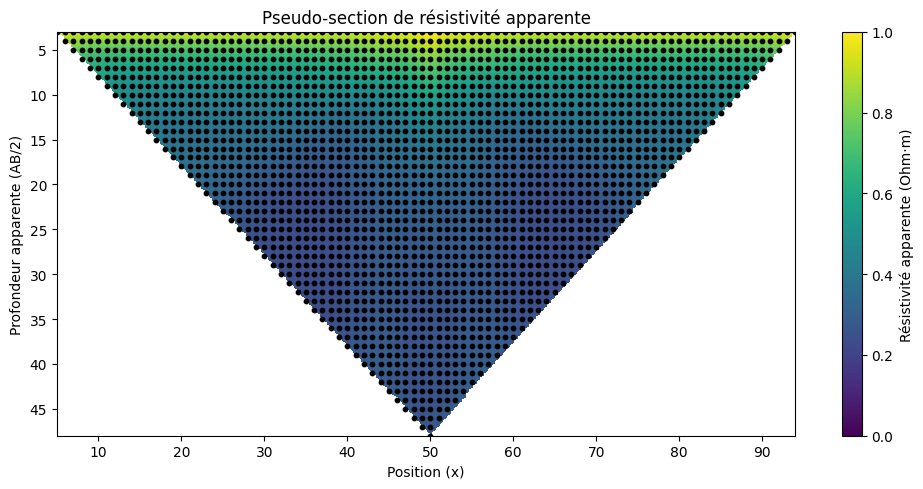

In [11]:
# plt.figure()
# plt.imshow(pseudo_section_array, origin='lower')
# plt.show()
x, z, rho_app = pseudo_section_array


# print(x, z, rho_app)
# pseudo = np.zeros((dim, dim))

# for idx, i in enumerate(x):
#     pseudo[z[idx], x[idx]] = rho_app[idx]

# plt.imshow(pseudo)
# plt.colorbar()

from scipy.interpolate import griddata

# grille régulière
xi = np.linspace(x.min(), x.max(), 200)
zi = np.linspace(z.min(), z.max(), 200)

XI, ZI = np.meshgrid(xi, zi)

# interpolation
RHOI = griddata((x, z), rho_app, (XI, ZI), method='cubic')

plt.figure(figsize=(10, 5))

# contour rempli
plt.contourf(XI, ZI, RHOI, levels=100)
# plt.imshow(RHOI, origin='lower')

# points de mesure (optionnel mais pro)
plt.scatter(x, z, c='k', s=10)

plt.gca().invert_yaxis()  # profondeur vers le bas

plt.xlabel("Position (x)")
plt.ylabel("Profondeur apparente (AB/2)")

plt.title("Pseudo-section de résistivité apparente")

plt.colorbar(label="Résistivité apparente (Ohm·m)")

plt.tight_layout()
plt.show()